# FESOM particles with built-in barycentric interpolation

Advect particles in FESOM2 output using Parcels v4. Horizontal velocities
`u`/`v` are face-registered in FESOM, so we area-average them onto the mesh
**nodes** and let `FieldSet.from_ugrid_conventions` assign the built-in
barycentric node interpolator (`UxLinearNodeConstantZC`). No custom
reconstruction kernel is needed.

In [1]:
import uxarray as ux
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import parcels
from uxarray.constants import INT_FILL_VALUE

/tmp/ipykernel_185090/1778420194.py:5: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  import parcels


## Load the FESOM grid and velocity data

In [2]:
grid_path = "/work/bk1450/b383184/ELPHE_hackathon/Double_gyre/FESOM_v2.7/1d/fesom.mesh.diag.nc"
grid = xr.open_dataset(grid_path).compute()

data_paths = [
    "/work/bk1450/b383184/ELPHE_hackathon/FESOM_1d/u.fesom.1950.nc",
    "/work/bk1450/b383184/ELPHE_hackathon/FESOM_1d/v.fesom.1950.nc",
    "/work/bk1450/b383184/ELPHE_hackathon/FESOM_1d/w.fesom.1950.nc",
]

ds = ux.open_mfdataset(grid, data_paths).load()
mesh = ux.open_grid(grid_path)
ds

<xarray.UxDataset> Size: 11GB
Dimensions:  (nz1: 40, time: 365, n_face: 73702, nz: 41, n_node: 37239)
Coordinates:
  * nz1      (nz1) float64 320B 4.519 14.01 24.45 ... 3.459e+03 3.814e+03
  * time     (time) datetime64[ns] 3kB 1950-01-01T23:50:00 ... 1950-12-31T23:...
  * nz       (nz) float64 328B 0.0 9.038 18.98 ... 3.29e+03 3.628e+03 4e+03
Dimensions without coordinates: n_face, n_node
Data variables:
    u        (time, nz1, n_face) float32 4GB 0.08384 -0.1518 ... -0.001951
    v        (time, nz1, n_face) float32 4GB 0.2584 0.1794 ... -0.003294
    w        (time, nz, n_node) float32 2GB -3.778e-08 -3.747e-08 ... nan nan
Attributes: (12/18)
    title:                               FESOM2 output
    FESOM_model:                         FESOM2
    FESOM_website:                       fesom.de
    FESOM_git_SHA:                       9aa93f20
    FESOM_MeshPath:                      /gxfs_work/geomar/smomw018/INPUT/FES...
    FESOM_mesh_representative_checksum:  
    ...                                  ...
    FESOM_use_floatice:                  0
    FESOM_whichEVP:                      0
    FESOM_evp_rheol_steps:               120
    FESOM_opt_visc:                      5
    FESOM_use_wsplit:                    0
    FESOM_autorotate_back_to_geo:        0

## Face -> node interpolation of U, V

FESOM stores `u`, `v` on triangle faces. We area-weight the surrounding faces
of each node to get node-registered velocities. `w` is already node-registered.

In [3]:
nf = mesh.node_face_connectivity.values            # (n_node, max_faces)
fill = mesh.node_face_connectivity.attrs.get("_FillValue", INT_FILL_VALUE)
areas = mesh.face_areas.values                     # (n_face,)

In [4]:
# def cell_to_vertex_3d(u_cell_3d, nf, areas, fill):
#     #Area-weighted face->node average for (nt, nz, n_face) -> (nt, nz, n_node)```
#     mask = nf != fill                              # (n_node, max_faces)
#     safe_idx = np.where(mask, nf, 0)               # (n_node, max_faces)

#     face_areas = areas[safe_idx] * mask            # (n_node, max_faces)
#     total_area = face_areas.sum(axis=1)            # (n_node,)

#     face_vals = u_cell_3d[:, :, safe_idx] * mask   # (nt, nz, n_node, max_faces)
#     weighted = (face_areas * face_vals).sum(axis=-1)
#     return weighted / total_area

def cell_to_vertex_3d(u_cell_3d, nf, areas, fill):
    mask       = nf != fill
    safe_idx   = np.where(mask, nf, 0)
    face_areas = areas[safe_idx] * mask
    total_area = face_areas.sum(axis=1)            # (n_node,)

    nt, nz, _ = u_cell_3d.shape
    out = np.empty((nt, nz, nf.shape[0]), dtype=u_cell_3d.dtype)
    for t in range(nt):                            # process one slab at a time
        fv = u_cell_3d[t][:, safe_idx] * mask      # (nz, n_node, max_faces)
        out[t] = (face_areas * fv).sum(-1) / total_area
    return out


In [5]:
u_nodal = cell_to_vertex_3d(ds["u"].values, nf, areas, fill)
v_nodal = cell_to_vertex_3d(ds["v"].values, nf, areas, fill)

In [6]:
ds["U"] = xr.DataArray(
    u_nodal, dims=["time", "nz1", "n_node"],
    coords={"time": ds.time, "nz1": ds.nz1},
)
ds["V"] = xr.DataArray(
    v_nodal, dims=["time", "nz1", "n_node"],
    coords={"time": ds.time, "nz1": ds.nz1},
)

# keep node-registered fields only and give W its capitalised name
ds = ds.drop_vars(["u", "v"]).rename_vars({"w": "W"})
ds

<xarray.UxDataset> Size: 7GB
Dimensions:  (time: 365, nz: 41, n_node: 37239, nz1: 40)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1950-01-01T23:50:00 ... 1950-12-31T23:...
  * nz       (nz) float64 328B 0.0 9.038 18.98 ... 3.29e+03 3.628e+03 4e+03
  * nz1      (nz1) float64 320B 4.519 14.01 24.45 ... 3.459e+03 3.814e+03
Dimensions without coordinates: n_node
Data variables:
    W        (time, nz, n_node) float32 2GB -3.778e-08 -3.747e-08 ... nan nan
    U        (time, nz1, n_node) float32 2GB -0.03404 0.146 ... -6.461e-05
    V        (time, nz1, n_node) float32 2GB 0.2189 0.3073 ... -0.00323
Attributes: (12/18)
    title:                               FESOM2 output
    FESOM_model:                         FESOM2
    FESOM_website:                       fesom.de
    FESOM_git_SHA:                       9aa93f20
    FESOM_MeshPath:                      /gxfs_work/geomar/smomw018/INPUT/FES...
    FESOM_mesh_representative_checksum:  
    ...                                  ...
    FESOM_use_floatice:                  0
    FESOM_whichEVP:                      0
    FESOM_evp_rheol_steps:               120
    FESOM_opt_visc:                      5
    FESOM_use_wsplit:                    0
    FESOM_autorotate_back_to_geo:        0

## Sanity check

Surface mean/std of the original face field `u` vs the node field `U` should be close.

In [7]:
print("u (face)  mean:", float(u_nodal.mean()), " std:", float(u_nodal.std()))
print("U (node)  mean:", float(ds.U.values.mean()), " std:", float(ds.U.values.std()))

u (face)  mean: 0.0007508920971304178  std: 0.10045427829027176
U (node)  mean: 0.0007508920971304178  std: 0.10045427829027176


## Build the FieldSet

`fesom_to_ugrid` standardises the dimension names; `from_ugrid_conventions`
detects U, V, W, assigns each a `UxGrid`, and picks the built-in interpolators.
`U`/`V` are node-registered, so they get `UxLinearNodeConstantZC` — the
**barycentric** node interpolation.

In [8]:
ds = parcels.convert.fesom_to_ugrid(ds)
print("dims:", dict(ds.sizes))

fieldset = parcels.FieldSet.from_ugrid_conventions(ds, mesh="spherical")

for name, field in fieldset.fields.items():
    interp = getattr(field, "interp_method", None)
    interp_name = interp.__name__ if interp is not None else "-"
    print(f"{name:>4s}  ->  {type(field).__name__:<11s}  interp={interp_name}")

INFO: Using known vertical dimension mapping: 'nz' (interfaces) and 'nz1' (centers).
INFO: Renaming vertical dimensions: {'nz': 'zf', 'nz1': 'zc'}
dims: {'time': 365, 'zf': 41, 'n_node': 37239, 'zc': 40}
   U  ->  Field        interp=UxLinearNodeConstantZC
   V  ->  Field        interp=UxLinearNodeConstantZC
  UV  ->  VectorField  interp=-
   W  ->  Field        interp=UxLinearNodeLinearZF
 UVW  ->  VectorField  interp=-


## Release particles and advect

The fieldset already uses the built-in barycentric interpolation, so we just run
the standard RK4 advection kernel. `AdvectionRK4` uses `fieldset.UV` (2D, surface);
swap to `AdvectionRK4_3D` (which uses `fieldset.UVW`) for fully 3D advection.

Domain extent: lon 0-35 E, lat 15-50 N.

In [9]:
lon_grid, lat_grid = np.meshgrid(
    np.linspace(8., 11., 10), 
    np.linspace(32., 33., 10)
)
lon = lon_grid.ravel()
lat = lat_grid.ravel()
z = np.full(lon.size, float(ds.zc.values[0]))   # surface layer

pset = parcels.ParticleSet(
    fieldset=fieldset,
    pclass=parcels.Particle,
    lon=lon,
    lat=lat,
    z=z,
)

output_file = parcels.ParticleFile(
    "output-fesom.parquet", outputdt=np.timedelta64(1, "D")
)

pset.execute(
    [parcels.kernels.AdvectionRK4_3D],
    runtime=np.timedelta64(30, "D"),
    dt=np.timedelta64(1, "h"),
    output_file=output_file,
    verbose_progress=True,
)

INFO: Output files are stored in output-fesom.parquet
Integration time: 1950-01-30T23:50:00 100%|██████████| [00:07<00:00, 366161.06it/s]


## Inspect and plot trajectories

In [10]:
df = parcels.read_particlefile("output-fesom.parquet")
df

lon,lat,z,time,particle_id
f32,f32,f32,datetime[ns],i64
8.0,32.0,4.51883,1950-01-01 23:50:00,0
8.333333,32.0,4.51883,1950-01-01 23:50:00,1
8.666667,32.0,4.51883,1950-01-01 23:50:00,2
9.0,32.0,4.51883,1950-01-01 23:50:00,3
9.333333,32.0,4.51883,1950-01-01 23:50:00,4
…,…,…,…,…
11.312807,30.91258,4.491628,1950-01-31 23:50:00,95
11.330872,30.759914,4.289404,1950-01-31 23:50:00,96
11.391004,30.902128,4.226694,1950-01-31 23:50:00,97


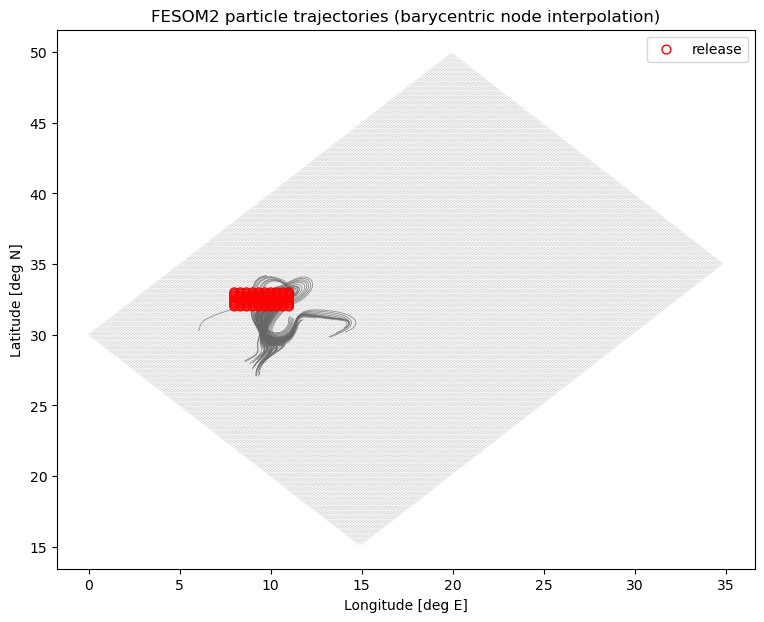

In [11]:
import matplotlib.tri as mtri

triang = mtri.Triangulation(
    ds.uxgrid.node_lon.values,
    ds.uxgrid.node_lat.values,
    triangles=ds.uxgrid.face_node_connectivity.values,
)

fig, ax = plt.subplots(figsize=(9, 7))
ax.triplot(triang, color="0.85", linewidth=0.2)

for traj in df.sort("time").partition_by("particle_id"):
    ax.plot(traj["lon"], traj["lat"], color="0.4", linewidth=0.6, alpha=0.7, zorder=2)

ax.scatter(lon, lat, facecolors="none", edgecolors="r", s=40, label="release", zorder=3)
ax.set_xlabel("Longitude [deg E]")
ax.set_ylabel("Latitude [deg N]")
ax.set_title("FESOM2 particle trajectories (barycentric node interpolation)")
ax.legend(loc="upper right")
plt.show()

## Compare interpolation schemes

The fieldset above uses **barycentric node** interpolation (`UxLinearNodeConstantZC`),
selected automatically because `U`/`V` are registered on `n_node`. Parcels picks
the interpolator purely from the data registration:

| Field dims | Interpolator | Scheme |
|---|---|---|
| `(zc, n_node)` | `UxLinearNodeConstantZC` | barycentric (linear) on nodes |
| `(zc, n_face)` | `UxConstantFaceConstantZC` | piecewise-constant on faces |

To compare them we build a **second fieldset** that keeps `u`/`v` on the faces
(no area-averaging), advect the **same particle seed** through each, and measure
how far the trajectories diverge. With real model data there is no analytic
ground truth, so trajectory separation is the meaningful Lagrangian metric.

### Build a face-registered fieldset (piecewise-constant)

This re-reads the velocities and keeps `u`/`v` on `n_face` (the FESOM-tutorial
path). Note this loads the velocity data a second time.

In [12]:
ds_face = ux.open_mfdataset(grid, data_paths).rename_vars(
    {"u": "U", "v": "V", "w": "W"}
).compute()

ds_face = parcels.convert.fesom_to_ugrid(ds_face)
fieldset_face = parcels.FieldSet.from_ugrid_conventions(ds_face, mesh="spherical")

for name, field in fieldset_face.fields.items():
    interp = getattr(field, "interp_method", None)
    interp_name = interp.__name__ if interp is not None else "-"
    print(f"{name:>4s}  ->  {type(field).__name__:<11s}  interp={interp_name}")

INFO: Using known vertical dimension mapping: 'nz' (interfaces) and 'nz1' (centers).
INFO: Renaming vertical dimensions: {'nz': 'zf', 'nz1': 'zc'}
   U  ->  Field        interp=UxConstantFaceConstantZC
   V  ->  Field        interp=UxConstantFaceConstantZC
  UV  ->  VectorField  interp=-
   W  ->  Field        interp=UxLinearNodeLinearZF
 UVW  ->  VectorField  interp=-


### Run the same seed through each scheme

We reuse the `lon`, `lat`, `z` release arrays from above and the same kernel /
timestep, so the only difference is the interpolation scheme.

In [13]:
lon_grid, lat_grid = np.meshgrid(
    np.linspace(8., 11., 10), 
    np.linspace(32., 33., 10)
)
lon = lon_grid.ravel()
lat = lat_grid.ravel()
z = np.full(lon.size, float(ds.zc.values[5]))   # z layer
z

array([62.4534, 62.4534, 62.4534, 62.4534, 62.4534, 62.4534, 62.4534,
       62.4534, 62.4534, 62.4534, 62.4534, 62.4534, 62.4534, 62.4534,
       62.4534, 62.4534, 62.4534, 62.4534, 62.4534, 62.4534, 62.4534,
       62.4534, 62.4534, 62.4534, 62.4534, 62.4534, 62.4534, 62.4534,
       62.4534, 62.4534, 62.4534, 62.4534, 62.4534, 62.4534, 62.4534,
       62.4534, 62.4534, 62.4534, 62.4534, 62.4534, 62.4534, 62.4534,
       62.4534, 62.4534, 62.4534, 62.4534, 62.4534, 62.4534, 62.4534,
       62.4534, 62.4534, 62.4534, 62.4534, 62.4534, 62.4534, 62.4534,
       62.4534, 62.4534, 62.4534, 62.4534, 62.4534, 62.4534, 62.4534,
       62.4534, 62.4534, 62.4534, 62.4534, 62.4534, 62.4534, 62.4534,
       62.4534, 62.4534, 62.4534, 62.4534, 62.4534, 62.4534, 62.4534,
       62.4534, 62.4534, 62.4534, 62.4534, 62.4534, 62.4534, 62.4534,
       62.4534, 62.4534, 62.4534, 62.4534, 62.4534, 62.4534, 62.4534,
       62.4534, 62.4534, 62.4534, 62.4534, 62.4534, 62.4534, 62.4534,
       62.4534, 62.4

In [31]:
def run(fs, tag):
    pset = parcels.ParticleSet(
        fieldset=fs, pclass=parcels.Particle, lon=lon, lat=lat, z=z
    )
    pset.execute(
        [parcels.kernels.AdvectionRK4_3D],
        runtime=np.timedelta64(360, "D"),
        dt=np.timedelta64(20, "m"),
        output_file=parcels.ParticleFile(
            f"output-fesom-{tag}.parquet", outputdt=np.timedelta64(4, "h"),mode="w"
        ),
        verbose_progress=True,
    )
    return parcels.read_particlefile(f"output-fesom-{tag}.parquet")


df_node = run(fieldset, "node")       # barycentric (UxLinearNodeConstantZC)
df_face = run(fieldset_face, "face")  # piecewise-constant (UxConstantFaceConstantZC)

INFO: Output files are stored in output-fesom-node.parquet
Integration time: 1950-12-27T19:50:00 100%|██████████| [03:39<00:00, 141734.10it/s]
INFO: Output files are stored in output-fesom-face.parquet
Integration time: 1950-12-27T19:50:00 100%|██████████| [03:13<00:00, 160969.26it/s]


### Quantify the separation

Great-circle distance between each particle's final position under the two
schemes.

In [32]:
def last_positions(df):
    return df.sort("time").group_by("particle_id").last().sort("particle_id")


a = last_positions(df_node)
b = last_positions(df_face)

R = 6371000.0  # Earth radius [m]
lat1, lon1 = np.deg2rad(a["lat"].to_numpy()), np.deg2rad(a["lon"].to_numpy())
lat2, lon2 = np.deg2rad(b["lat"].to_numpy()), np.deg2rad(b["lon"].to_numpy())
dphi, dlmb = lat2 - lat1, lon2 - lon1
hav = np.sin(dphi / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlmb / 2) ** 2
sep_km = 2 * R * np.arcsin(np.sqrt(hav)) / 1000.0

print(f"node vs face separation after 30 d:")
print(f"  mean   = {sep_km.mean():.1f} km")
print(f"  median = {np.median(sep_km):.1f} km")
print(f"  max    = {sep_km.max():.1f} km")

node vs face separation after 30 d:
  mean   = 739.0 km
  median = 609.0 km
  max    = 1931.8 km


### Overlay the trajectories

Blue = barycentric node interpolation, orange = piecewise-constant face
interpolation. Divergence is largest in regions of strong velocity gradients
(jets, eddies), where the zeroth-order face scheme is least accurate.

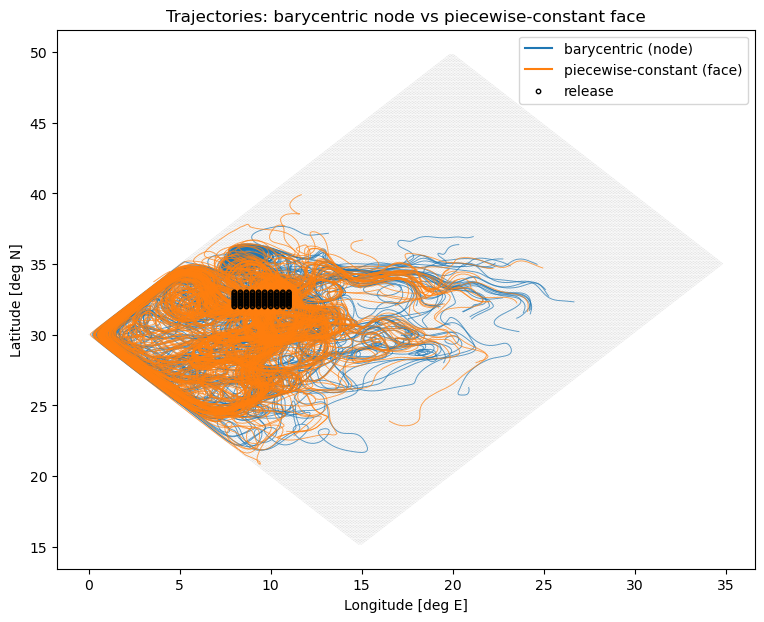

In [33]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.triplot(triang, color="0.9", linewidth=0.2)

for traj in df_node.sort("time").partition_by("particle_id"):
    ax.plot(traj["lon"], traj["lat"], color="C0", linewidth=0.7, alpha=0.7, zorder=2)
for traj in df_face.sort("time").partition_by("particle_id"):
    ax.plot(traj["lon"], traj["lat"], color="C1", linewidth=0.7, alpha=0.7, zorder=2)

ax.plot([], [], color="C0", label="barycentric (node)")
ax.plot([], [], color="C1", label="piecewise-constant (face)")
ax.scatter(lon, lat, facecolors="none", edgecolors="k", s=10, label="release", zorder=3)
ax.set_xlabel("Longitude [deg E]")
ax.set_ylabel("Latitude [deg N]")
ax.set_title("Trajectories: barycentric node vs piecewise-constant face")
ax.legend(loc="upper right")
plt.show()

### Separation growth over time

Join the two runs on `(particle_id, time)` and compute the great-circle
separation at every output step, so we can see how the trajectories diverge
through the 30-day integration rather than just at the end.

In [34]:
import polars as pl

R = 6371000.0  # Earth radius [m]


def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.deg2rad, (lat1, lon1, lat2, lon2))
    dphi, dlmb = lat2 - lat1, lon2 - lon1
    hav = np.sin(dphi / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlmb / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(hav)) / 1000.0


merged = df_node.join(
    df_face, on=["particle_id", "time"], suffix="_face"
).sort(["particle_id", "time"])

sep = haversine_km(
    merged["lat"].to_numpy(), merged["lon"].to_numpy(),
    merged["lat_face"].to_numpy(), merged["lon_face"].to_numpy(),
)
merged = merged.with_columns(pl.Series("sep_km", sep))

# days since release, for the x-axis
t0 = merged["time"].min()
merged = merged.with_columns(
    ((pl.col("time") - t0).dt.total_seconds() / 86400.0).alias("days")
)

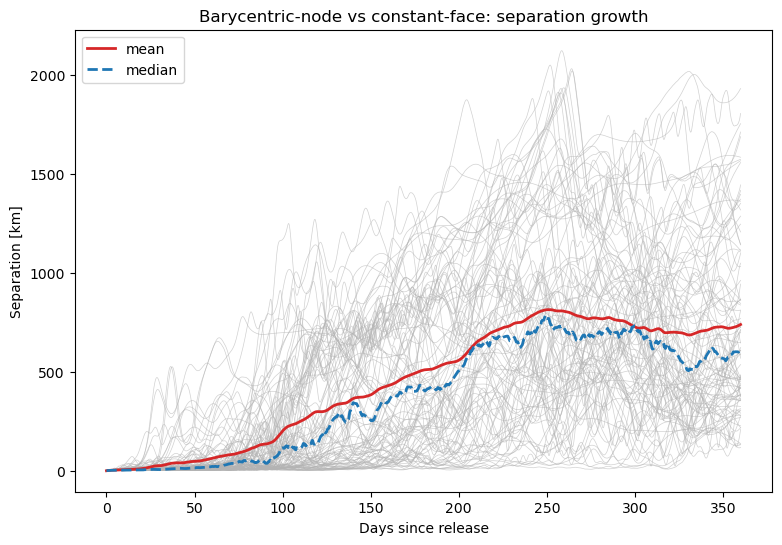

In [35]:
fig, ax = plt.subplots(figsize=(9, 6))

# per-particle separation (thin grey)
for traj in merged.partition_by("particle_id"):
    ax.plot(traj["days"], traj["sep_km"], color="0.7", linewidth=0.5, alpha=0.6)

# mean and median across particles at each time
stats = (
    merged.group_by("days")
    .agg(
        pl.col("sep_km").mean().alias("mean"),
        pl.col("sep_km").median().alias("median"),
    )
    .sort("days")
)
ax.plot(stats["days"], stats["mean"], color="C3", linewidth=2.0, label="mean")
ax.plot(stats["days"], stats["median"], color="C0", linewidth=2.0,
        linestyle="--", label="median")

ax.set_xlabel("Days since release")
ax.set_ylabel("Separation [km]")
ax.set_title("Barycentric-node vs constant-face: separation growth")
ax.legend(loc="upper left")
plt.show()

## Add a third scheme: least-squares face reconstruction

`UxConstantFaceConstantZC` is zeroth-order (it returns the host face's value).
A higher-order alternative for face-registered data is a **cell-view linear
least-squares reconstruction**: for each face we fit a planar gradient from its
neighbouring face values and evaluate it at the particle position. This is a
custom interpolator, `LinearFaceRecon`, attached to the *face* fieldset.

The gradient coefficients are precomputed once per face and stored on the
`uxgrid` by `build_reconstruction_terms`. Faces with fewer than two independent
neighbours fall back to the piecewise-constant value.

In [36]:
DEG2M = 1852.0 * 60.0  # metres per degree (matches Ux_Velocity unit conversion)


def local_offsets(mesh, lon_c, lat_c, lon, lat):
    """Local planar offset (dx, dy) [m] of (lon, lat) from a centroid."""
    if mesh == "spherical":
        dlon = ((np.asarray(lon) - lon_c + 180.0) % 360.0) - 180.0
        dx = dlon * np.cos(np.deg2rad(lat_c)) * DEG2M
        dy = (np.asarray(lat) - lat_c) * DEG2M
    else:  # flat mesh: coordinates are already planar (x, y)
        dx = np.asarray(lon) - lon_c
        dy = np.asarray(lat) - lat_c
    return dx, dy


def build_reconstruction_terms(uxgrid, mesh):
    """Precompute per-face least-squares gradient coefficients.

    Adds to uxgrid._ds: gradient_coeff_x/_y, recon_face_neighbors (fill -> self),
    recon_neighbor_mask (1.0 valid / 0.0 absent), all (n_face, n_max_face_faces).
    """
    nbr = np.asarray(uxgrid.face_face_connectivity.values)  # (F, K)
    flon = np.asarray(uxgrid.face_lon.values)
    flat = np.asarray(uxgrid.face_lat.values)

    valid = nbr != INT_FILL_VALUE
    nbr_safe = np.where(valid, nbr, 0)

    dx, dy = local_offsets(
        mesh, flon[:, None], flat[:, None], flon[nbr_safe], flat[nbr_safe]
    )
    dx = np.where(valid, dx, 0.0)  # absent -> no contribution
    dy = np.where(valid, dy, 0.0)

    X2 = np.sum(dx * dx, axis=1)
    Y2 = np.sum(dy * dy, axis=1)
    XY = np.sum(dx * dy, axis=1)
    d = X2 * Y2 - XY * XY

    # cells with < 2 independent neighbours give d == 0 -> zero-gradient fallback
    ok = d != 0.0
    inv_d = np.where(ok, 1.0 / np.where(ok, d, 1.0), 0.0)

    gx = (dx * Y2[:, None] - dy * XY[:, None]) * inv_d[:, None]
    gy = (dy * X2[:, None] - dx * XY[:, None]) * inv_d[:, None]
    gx = np.where(valid, gx, 0.0)
    gy = np.where(valid, gy, 0.0)

    dims = ("n_face", "n_max_face_faces")
    uxgrid._ds["gradient_coeff_x"] = xr.DataArray(gx, dims=dims)
    uxgrid._ds["gradient_coeff_y"] = xr.DataArray(gy, dims=dims)
    uxgrid._ds["recon_face_neighbors"] = xr.DataArray(nbr_safe, dims=dims)
    uxgrid._ds["recon_neighbor_mask"] = xr.DataArray(valid.astype(np.float64), dims=dims)
    return uxgrid

In [37]:
# Custom interpolator: linear least-squares reconstruction on faces, constant in zc.
def LinearFaceRecon(particle_positions, grid_positions, field):
    ti = grid_positions["T"]["index"]
    zi = grid_positions["Z"]["index"]
    fi = grid_positions["FACE"]["index"]

    uxg = field.grid.uxgrid
    gx = uxg._ds["gradient_coeff_x"].values[fi]      # (M, K)
    gy = uxg._ds["gradient_coeff_y"].values[fi]
    nb = uxg._ds["recon_face_neighbors"].values[fi]  # (M, K)
    mask = uxg._ds["recon_neighbor_mask"].values[fi]

    uc = field.data.values[ti, zi, fi]                       # (M,)
    un = field.data.values[ti[:, None], zi[:, None], nb]     # (M, K)
    du = (un - uc[:, None]) * mask
    ax = np.sum(gx * du, axis=1)
    ay = np.sum(gy * du, axis=1)

    flon = uxg.face_lon.values[fi]
    flat = uxg.face_lat.values[fi]
    dx, dy = local_offsets(
        field.grid._mesh, flon, flat,
        particle_positions["lon"], particle_positions["lat"],
    )
    return uc + ax * dx + ay * dy

### Build a least-squares fieldset and run

We build a fresh face fieldset, precompute the reconstruction terms on its grid,
and override the `U`/`V` interpolators with `LinearFaceRecon`. The vector field
`UVW` automatically uses whatever each component's `interp_method` is set to.

In [38]:
fieldset_lsq = parcels.FieldSet.from_ugrid_conventions(ds_face, mesh="spherical")

build_reconstruction_terms(fieldset_lsq.fields["U"].grid.uxgrid, mesh="spherical")

fieldset_lsq.fields["U"].interp_method = LinearFaceRecon
fieldset_lsq.fields["V"].interp_method = LinearFaceRecon

for name in ("U", "V", "W"):
    interp = fieldset_lsq.fields[name].interp_method
    print(f"{name:>4s}  ->  interp={interp.__name__}")

   U  ->  interp=LinearFaceRecon
   V  ->  interp=LinearFaceRecon
   W  ->  interp=UxLinearNodeLinearZF


In [39]:
df_lsq = run(fieldset_lsq, "lsq")   # least-squares face reconstruction

INFO: Output files are stored in output-fesom-lsq.parquet
Integration time: 1950-12-27T19:50:00 100%|██████████| [04:07<00:00, 125898.87it/s]


### Three-way comparison

Pairwise great-circle separation of final positions between all three schemes,
the combined trajectory overlay, and the separation growth of the two face
schemes (constant vs least-squares) relative to the barycentric node scheme.

In [40]:
def final_sep_km(dfa, dfb):
    a = dfa.sort("time").group_by("particle_id").last().sort("particle_id")
    b = dfb.sort("time").group_by("particle_id").last().sort("particle_id")
    return haversine_km(
        a["lat"].to_numpy(), a["lon"].to_numpy(),
        b["lat"].to_numpy(), b["lon"].to_numpy(),
    )


pairs = {
    "node  vs face": (df_node, df_face),
    "node  vs lsq ": (df_node, df_lsq),
    "face  vs lsq ": (df_face, df_lsq),
}
print(f"{'pair':<14s} {'mean':>8s} {'median':>8s} {'max':>8s}   [km], 30 d")
for label, (da, db) in pairs.items():
    s = final_sep_km(da, db)
    print(f"{label:<14s} {s.mean():8.1f} {np.median(s):8.1f} {s.max():8.1f}")

pair               mean   median      max   [km], 30 d
node  vs face     739.0    609.0   1931.8
node  vs lsq      817.9    671.4   8371.0
face  vs lsq      704.8    549.4   8651.3


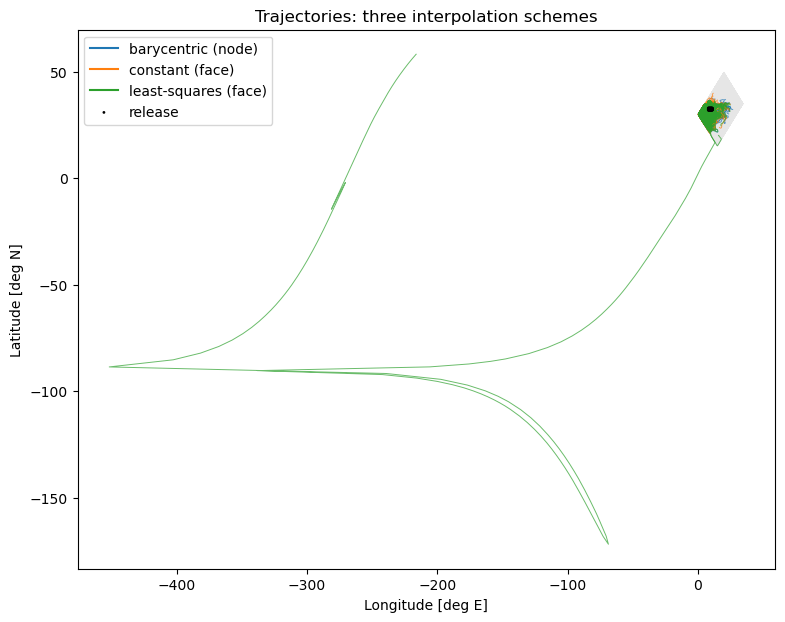

In [46]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.triplot(triang, color="0.9", linewidth=0.2)

series = [
    (df_node, "C0", "barycentric (node)"),
    (df_face, "C1", "constant (face)"),
    (df_lsq, "C2", "least-squares (face)"),
]
for df_i, color, _ in series:
    for traj in df_i.sort("time").partition_by("particle_id"):
        ax.plot(traj["lon"], traj["lat"], color=color, linewidth=0.7, alpha=0.7, zorder=2)
for _, color, label in series:
    ax.plot([], [], color=color, label=label)

ax.scatter(lon, lat, facecolors="none", edgecolors="k", s=1, label="release", zorder=3)
ax.set_xlabel("Longitude [deg E]")
ax.set_ylabel("Latitude [deg N]")
ax.set_title("Trajectories: three interpolation schemes")
ax.legend(loc="upper left")
plt.show()

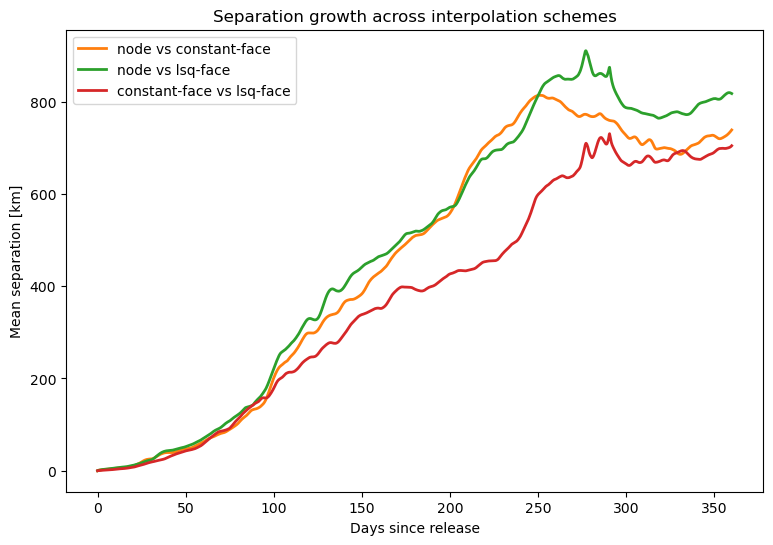

In [42]:
def sep_stats_over_time(dfa, dfb):
    m = dfa.join(dfb, on=["particle_id", "time"], suffix="_b").sort(["particle_id", "time"])
    s = haversine_km(
        m["lat"].to_numpy(), m["lon"].to_numpy(),
        m["lat_b"].to_numpy(), m["lon_b"].to_numpy(),
    )
    m = m.with_columns(pl.Series("sep_km", s))
    t0 = m["time"].min()
    m = m.with_columns(((pl.col("time") - t0).dt.total_seconds() / 86400.0).alias("days"))
    return m.group_by("days").agg(pl.col("sep_km").mean().alias("mean")).sort("days")


fig, ax = plt.subplots(figsize=(9, 6))
for (da, db), label, color in [
    ((df_node, df_face), "node vs constant-face", "C1"),
    ((df_node, df_lsq), "node vs lsq-face", "C2"),
    ((df_face, df_lsq), "constant-face vs lsq-face", "C3"),
]:
    st = sep_stats_over_time(da, db)
    ax.plot(st["days"], st["mean"], color=color, linewidth=2.0, label=label)

ax.set_xlabel("Days since release")
ax.set_ylabel("Mean separation [km]")
ax.set_title("Separation growth across interpolation schemes")
ax.legend(loc="upper left")
plt.show()

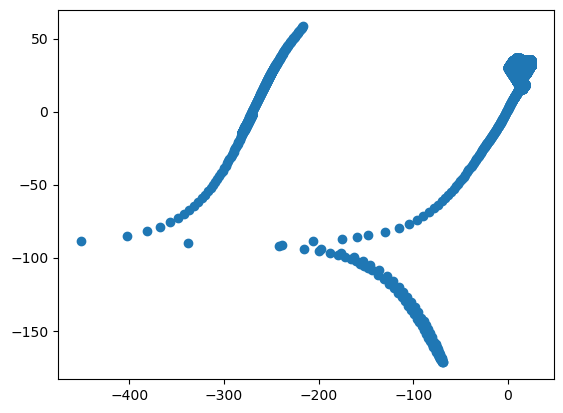

In [43]:
plt.scatter(df_lsq['lon'],df_lsq['lat'])

## Particles leaving the domain

In [45]:
from matplotlib.path import Path
# ---- 1. Build domain polygon from the FESOM mesh (once) ----
# mesh = xr.open_dataset('fesom.mesh.diag.nc')
mlon = np.rad2deg(grid.lon.values) if grid.lon.max() < 7 else grid.lon.values
mlat = np.rad2deg(grid.lat.values) if grid.lat.max() < 7 else grid.lat.values

# Convex hull of mesh nodes -> domain boundary (good for an idealized basin).
from scipy.spatial import ConvexHull
pts  = np.column_stack([mlon, mlat])
hull = ConvexHull(pts)
domain = Path(pts[hull.vertices])

def n_left_domain(df, pad=0.0):
    """Count particles whose trajectory ever exits the domain polygon."""
    inside = domain.contains_points(df[['lon', 'lat']].values, radius=pad)
    df = df.assign(inside=inside)
    # a particle "left" if it was inside at least once and outside at least once
    per = df.groupby('particle_id')['inside']
    ever_outside = (~per.transform('all')).groupby(df['particle_id']).first()
    return int(ever_outside.sum()), df.particle_id.nunique()

# ---- 2. Tally each experiment ----
experiments = {
    'base': 'output-fesom.parquet',
    'face': 'output-fesom-face.parquet',
    'lsq' : 'output-fesom-lsq.parquet',
    'node': 'output-fesom-node.parquet',
}

print(f"{'experiment':<8} {'left':>6} {'total':>6}  {'%':>6}")
for name, f in experiments.items():
    try:
        df = pd.read_parquet(f)
    except Exception as e:
        print(f"{name:<8}  SKIP ({type(e).__name__}: file unreadable)")
        continue
    left, total = n_left_domain(df)
    print(f"{name:<8} {left:>6} {total:>6}  {100*left/total:>5.1f}%")


experiment   left  total       %
base      SKIP (NameError: file unreadable)
face      SKIP (NameError: file unreadable)
lsq       SKIP (NameError: file unreadable)
node      SKIP (NameError: file unreadable)
